In [1]:
# Import required libraries
from pathlib import Path
import torch

from tree_detection_framework.constants import DATA_FOLDER
from tree_detection_framework.detection.SAM3_detector import SAM3Detector
from tree_detection_framework.postprocessing.postprocessing import (
    multi_region_NMS,
    suppress_tile_boundary_with_NMS,
)
from tree_detection_framework.preprocessing.preprocessing import (
    create_dataloader,
    visualize_dataloader,
)

/ofo-share/repos/amritha/conda/envs/tdf-sam3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/ofo-share/repos/amritha/conda/envs/tdf-sam3/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.2'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
# The path to a folder of raster images, e.g. orthomosaics stor
RASTER_FOLDER_PATH = Path(DATA_FOLDER, "emerald-point-ortho")
RASTER_FILE_PATH = Path(RASTER_FOLDER_PATH, "ortho.tif")
# Prediction file path
OUTPUT_PREDICTIONS_FILE_PATH = Path(
    DATA_FOLDER, "emerald-point-ortho-sam3-predictions.gpkg"
)
# The size of the chips in pixels
CHIP_SIZE = 2000
# The stride between chips in pixels
CHIP_STRIDE = 1000
# The spatial resolution that the data is sampled to in meters/pix
RESOLUTION = 0.05
# The number of samples in a batch
BATCH_SIZE = 4
# Any detections below this threshold will be discarded
MIN_CONFIDENCE_THRESHOLD = 0.3
# Detections that overlap more than this threshold will be suppressed
IOU_NMS_THRESHOLD = 0.3

# How many tiles to show
N_VIS_TILES = 3

# The Hugging Face token to use for downloading the model. Refer README for instructions on how to get a token.
HUGGING_FACE_TOKEN = "<ENTER_YOUR_HUGGING_FACE_TOKEN>"


# The device to use for inference, GPU or CPU
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
dataloader = create_dataloader(
    raster_folder_path=RASTER_FOLDER_PATH,
    chip_size=CHIP_SIZE,
    chip_stride=CHIP_STRIDE,
    resolution=RESOLUTION,
    batch_size=BATCH_SIZE,
)

INFO:root:Units = Units.PIXELS
INFO:root:Stride = 1000


In [ ]:
detector = SAM3Detector(huggingface_token=HUGGING_FACE_TOKEN)

In [5]:
outputs = detector.predict(dataloader)

Performing prediction on batches: 100%|██████████| 9/9 [03:07<00:00, 20.78s/it]


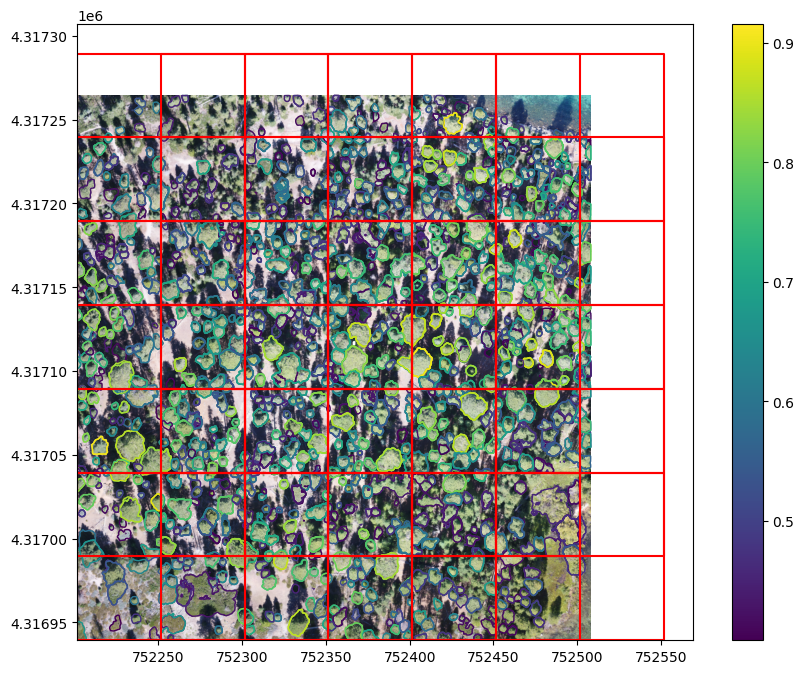

<Axes: >

In [6]:
outputs.plot(
    visualization_column="score", bounds_color="r", raster_file=RASTER_FILE_PATH
)

INFO:root:Bound have overlap, running across-region NMS


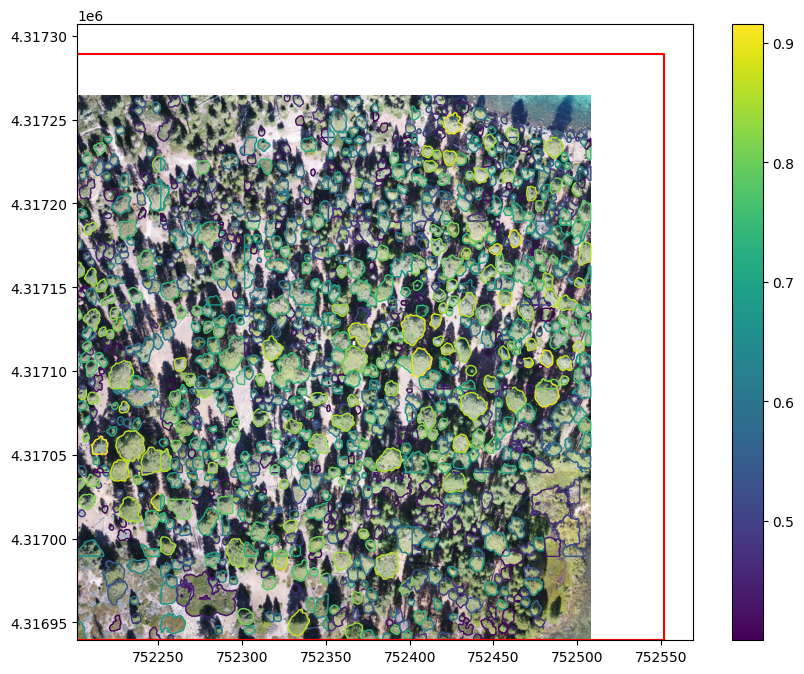

<Axes: >

In [ ]:
NMS_outputs = multi_region_NMS(
    outputs,
    confidence_column="score",
    threshold=IOU_NMS_THRESHOLD,
)

NMS_outputs.plot(
    visualization_column="score", bounds_color="r", raster_file=RASTER_FILE_PATH
)

In [8]:
NMS_outputs.save(OUTPUT_PREDICTIONS_FILE_PATH)

INFO:pyogrio._io:Created 1,002 records
